In [1]:
import pandas as pd
import numpy as np
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'
tips = pd.read_csv(url)
tips['tip_pct'] = (tips['tip'] / tips['total_bill'] * 100).round(1)
print(f"tips: {tips.shape[0]} wierszy, {tips.shape[1]} kolumn")

tips: 244 wierszy, 8 kolumn


In [2]:
lotniska = pd.DataFrame({
'miasto': ['Warszawa', 'Kraków', 'Gdańsk', 'Wrocław', 'Katowice',
'Poznań', 'Rzeszów', 'Łódź', 'Szczecin', 'Bydgoszcz'],
'kod': ['WAW', 'KRK', 'GDN', 'WRO', 'KTW',
'POZ', 'RZE', 'LCJ', 'SZZ', 'BZG'],
'pasazerowie_mln': [18.9, 9.3, 5.7, 3.8, 5.4,
2.6, 0.9, 0.3, 0.6, 0.4],
'linie': [85, 42, 35, 28, 32, 22, 12, 5, 8, 6],
'region': ['Mazowieckie', 'Małopolskie', 'Pomorskie', 'Dolnośląskie',
'Śląskie',
'Wielkopolskie', 'Podkarpackie', 'Łódzkie', 'Zachodniopomorskie',
'Kujawsko-Pomorskie']
})
lotniska.index = lotniska['kod']
print(lotniska[['miasto', 'pasazerowie_mln', 'linie', 'region']])

        miasto  pasazerowie_mln  linie              region
kod                                                       
WAW   Warszawa             18.9     85         Mazowieckie
KRK     Kraków              9.3     42         Małopolskie
GDN     Gdańsk              5.7     35           Pomorskie
WRO    Wrocław              3.8     28        Dolnośląskie
KTW   Katowice              5.4     32             Śląskie
POZ     Poznań              2.6     22       Wielkopolskie
RZE    Rzeszów              0.9     12        Podkarpackie
LCJ       Łódź              0.3      5             Łódzkie
SZZ   Szczecin              0.6      8  Zachodniopomorskie
BZG  Bydgoszcz              0.4      6  Kujawsko-Pomorskie


## Zad 1a

In [10]:
pierwsze = lotniska.iloc[ :3]
print(trzy)
drugie = lotniska.iloc[4:8, [0, 2]]
print(drugie)
trzecie = lotniska.iloc[::-2]
print(trzecie)

       miasto  kod  pasazerowie_mln  linie       region
kod                                                    
WAW  Warszawa  WAW             18.9     85  Mazowieckie
KRK    Kraków  KRK              9.3     42  Małopolskie
GDN    Gdańsk  GDN              5.7     35    Pomorskie
       miasto  pasazerowie_mln
kod                           
KTW  Katowice              5.4
POZ    Poznań              2.6
RZE   Rzeszów              0.9
LCJ      Łódź              0.3
        miasto  kod  pasazerowie_mln  linie              region
kod                                                            
BZG  Bydgoszcz  BZG              0.4      6  Kujawsko-Pomorskie
LCJ       Łódź  LCJ              0.3      5             Łódzkie
POZ     Poznań  POZ              2.6     22       Wielkopolskie
WRO    Wrocław  WRO              3.8     28        Dolnośląskie
KRK     Kraków  KRK              9.3     42         Małopolskie


## Zad 1b

In [14]:
zad_pierwsze = lotniska.loc['KRK']
print(zad_pierwsze)
zad_drugie = lotniska.loc[['WAW', 'GDN', 'KTW'],['miasto', 'linie']]
print(zad_drugie)
zad_trzecie = lotniska.loc[lotniska['pasazerowie_mln'] > 5]
print(zad_trzecie)

miasto                  Kraków
kod                        KRK
pasazerowie_mln            9.3
linie                       42
region             Małopolskie
Name: KRK, dtype: object
       miasto  linie
kod                 
WAW  Warszawa     85
GDN    Gdańsk     35
KTW  Katowice     32
       miasto  kod  pasazerowie_mln  linie       region
kod                                                    
WAW  Warszawa  WAW             18.9     85  Mazowieckie
KRK    Kraków  KRK              9.3     42  Małopolskie
GDN    Gdańsk  GDN              5.7     35    Pomorskie
KTW  Katowice  KTW              5.4     32      Śląskie


## Zad 1c

In [18]:
maska_M = lotniska['region'].str.startswith('M')
liczba_M = lotniska[maska_M].shape[0]
print(lotniska[maska_M][['miasto', 'region']])

lotniska['stosunek_pas_linia'] = (lotniska['pasazerowie_mln'])
top_oblozenie = lotniska.nlargest(3, 'pax_per_linia')
print(top_oblozenie[['miasto', 'pasazerowie_mln', 'linie', 'stosunek_pas_linia']])

       miasto       region
kod                       
WAW  Warszawa  Mazowieckie
KRK    Kraków  Małopolskie
       miasto  pasazerowie_mln  linie  stosunek_pas_linia
kod                                                      
WAW  Warszawa             18.9     85                18.9
KRK    Kraków              9.3     42                 9.3
GDN    Gdańsk              5.7     35                 5.7


##  Runda 1

In [ ]:
# "Ile rachunków mieliśmy w piątek?"
friday_count = tips[tips['day'] == 'Fri'].shape[0]
# "Ile rachunków złożyły grupy 1-osobowe? A 6-osobowe?"
group_counts = tips['size'].value_counts()
jedno_osobowe = group_counts.get(1, 0)
szescio_osobowe = group_counts.get(6, 0)
# "Jaki jest najwyższy rachunek od kobiety?"
kobieta_rachunek = tips.loc[tips['sex'] == 'Female', 'total_bill'].max()
print(f"Liczba rachunków w piątek: {friday_count}")
print(f"Liczba grup 1-osobowych: {jedno_osobowe}")
print(f"Liczba grup 6-osobowych: {szescio_osobowe}")
print(f"Najwyższy rachunek wystawiony kobiecie: {kobieta_rachunek}$")

Liczba rachunków w piątek: 19
Liczba grup 1-osobowych: 4
Liczba grup 6-osobowych: 4
Najwyższy rachunek wystawiony kobiecie: 44.3$


## Runda 2

In [ ]:
# "Ilu niepalących mężczyzn jadło u nas obiad w weekend?"
weekend = ['Sat', 'Sun']
niepalacy_mezczyzni_weekend = tips[
    (tips['sex'] == 'Male') & 
    (tips['smoker'] == 'No') & 
    (tips['time'] == 'Dinner') & 
    (tips['day'].isin(weekend))
].shape[0]
print(f"Niepalący mężczyźni (obiad, weekend): {niepalacy_mezczyzni_weekend}")
# "Podaj średni rachunek dla dużych grup (4+) w czwartek."
sredni_czwartek_4plus = tips[
    (tips['day'] == 'Thur') & 
    (tips['size'] >= 4)
]['total_bill'].mean()
print(f"Średni rachunek (Czwartek, grupy 4+): {sredni_czwartek_4plus:.2f}$")
# "Ilu klientów dało napiwek powyżej 25% przy rachunku poniżej 10$?"
hojni_klienci = tips[
    (tips['tip'] / tips['total_bill'] > 0.25) & 
    (tips['total_bill'] < 10)
]
print(f" Liczba 'podejrzanie hojnych' klientów: {hojni_klienci.shape[0]}")

1. Niepalący mężczyźni (obiad, weekend): 75
2. Średni rachunek (Czwartek, grupy 4+): 31.34$
3. Liczba 'podejrzanie hojnych' klientów: 4


## Runda 3

In [35]:
# "Rachunki z weekendu (Sat, Sun) w zakresie 15-30$ — ile ich jest?"
weekend = ['Sat', 'Sun']
rachunki_15_30 = tips[
    (tips['day'].isin(weekend)) & 
    (tips['total_bill'].between(15, 30))
]

print(f"1. Liczba rachunków weekendowych (15-30$): {len(rachunki_15_30)}")
rachunki_query = tips.query("day in ['Sat', 'Sun'] and 15 <= total_bill <= 30")
print(f"2. Wynik z query(): {len(rachunki_query)}")

# Bonus
srednia = tips['total_bill'].mean()
wynik_bonus = tips.query(
    "sex == 'Male' and smoker == 'No' and time == 'Dinner' and total_bill > @srednia"
)

print(f"Liczba rachunków powyżej średniej: {len(wynik_bonus)}")

1. Liczba rachunków weekendowych (15-30$): 93
2. Wynik z query(): 93
Liczba rachunków powyżej średniej: 33


In [37]:
filmy = pd.DataFrame({
'tytul': ['Incepcja', 'Parasite', 'Avengers: Endgame', 'Joker', 'Coco',
'Get Out', 'Dune', 'Whiplash', 'Mad Max: Fury Road', 'Spider-Man: No Way Home',
'The Batman', 'Everything Everywhere', 'Oppenheimer', 'Barbie', 'La La Land',
'Blade Runner 2049', 'Knives Out', '1917', 'Jojo Rabbit',
'Midsommar'],
'rok': [2010, 2019, 2019, 2019, 2017,
2017, 2021, 2014, 2015, 2021,
2022, 2022, 2023, 2023, 2016,
2017, 2019, 2019, 2019, 2019],
'gatunek': ['Sci-Fi', 'Thriller', 'Akcja', 'Dramat', 'Animacja',
'Horror', 'Sci-Fi', 'Dramat', 'Akcja', 'Akcja',
'Akcja', 'Sci-Fi', 'Dramat', 'Komedia', 'Musical',
'Sci-Fi', 'Kryminał', 'Wojenny', 'Komedia', 'Horror'],
'budzet_mln': [160, 11, 356, 55, 175,
4.5, 165, 3.3, 150, 200,
185, 25, 100, 145, 30,
150, 40, 95, 14, 9],
'przychod_mln': [836, 258, 2798, 1074, 807,
255, 407, 49, 380, 1916,
771, 141, 952, 1442, 447,
259, 311, 384, 90, 48],
'ocena_imdb': [8.8, 8.5, 8.4, 8.4, 8.4,
7.7, 8.0, 8.5, 8.1, 8.2,
7.8, 7.8, 8.3, 6.8, 8.0,
8.0, 7.9, 8.3, 7.9, 7.1]
})
filmy['roi'] = (filmy['przychod_mln'] / filmy['budzet_mln']).round(1)
print(filmy[['tytul', 'gatunek', 'budzet_mln', 'przychod_mln', 'roi',
'ocena_imdb']])

                      tytul   gatunek  budzet_mln  przychod_mln   roi  \
0                  Incepcja    Sci-Fi       160.0           836   5.2   
1                  Parasite  Thriller        11.0           258  23.5   
2         Avengers: Endgame     Akcja       356.0          2798   7.9   
3                     Joker    Dramat        55.0          1074  19.5   
4                      Coco  Animacja       175.0           807   4.6   
5                   Get Out    Horror         4.5           255  56.7   
6                      Dune    Sci-Fi       165.0           407   2.5   
7                  Whiplash    Dramat         3.3            49  14.8   
8        Mad Max: Fury Road     Akcja       150.0           380   2.5   
9   Spider-Man: No Way Home     Akcja       200.0          1916   9.6   
10               The Batman     Akcja       185.0           771   4.2   
11    Everything Everywhere    Sci-Fi        25.0           141   5.6   
12              Oppenheimer    Dramat       100.0  

## Zad 3a

In [49]:
# 1. TOP-5 filmów wg przychodu (nlargest)
top_przychody = filmy.nlargest(5, 'przychod_mln')
print(top_przychody[['tytul', 'przychod_mln']])

# 2. TOP-5 filmów wg ROI (zwrot z inwestycji) — czy to te same filmy?
filmy_roi = filmy.nlargest(5, 'roi')
print(filmy_roi[['tytul', 'roi']])
# 3. 5 filmów z najwyższą oceną IMDB
top_imdb = filmy.nlargest(5, 'ocena_imdb')
print(top_imdb[['tytul', 'ocena_imdb']])
# 4. Które filmy miały budżet poniżej 15 mln$? Ile zarobiły?
ponizej_pietnascie = filmy.query('budzet_mln < 15')
print(ponizej_pietnascie[['tytul', 'budzet_mln', 'przychod_mln', 'roi']])

                      tytul  przychod_mln
2         Avengers: Endgame          2798
9   Spider-Man: No Way Home          1916
13                   Barbie          1442
3                     Joker          1074
12              Oppenheimer           952
         tytul   roi
5      Get Out  56.7
1     Parasite  23.5
3        Joker  19.5
14  La La Land  14.9
7     Whiplash  14.8
               tytul  ocena_imdb
0           Incepcja         8.8
1           Parasite         8.5
7           Whiplash         8.5
2  Avengers: Endgame         8.4
3              Joker         8.4
          tytul  budzet_mln  przychod_mln   roi
1      Parasite        11.0           258  23.5
5       Get Out         4.5           255  56.7
7      Whiplash         3.3            49  14.8
18  Jojo Rabbit        14.0            90   6.4
19    Midsommar         9.0            48   5.3


## Zad 3b

In [56]:
# 1. "Ile filmów z gatunku Akcja mamy? Jaki ich średni ROI?"
akcja = filmy[filmy['gatunek'] == 'Akcja']
liczba_akcja = len(akcja)
sredni_roi_akcja = akcja['roi'].mean()
print(f"Filmy Akcji: {liczba_akcja}, Średni ROI: {sredni_roi_akcja:.2f}")
# 2. "Filmy z oceną >= 8.0 I budżetem < 50 mln$ — to nasze 'perełki'. Które to?"
perelki = filmy.query("budzet_mln < 50 and ocena_imdb >= 8.0")
print(perelki)
# 3. "Porównaj średni ROI per gatunek. Który gatunek daje najlepszy zwrot?"
print("średni ROI na gatunek:")
lista_gatunkow = filmy['gatunek'].unique()

for g in lista_gatunkow:
    srednia = filmy[filmy['gatunek'] == g]['roi'].mean()
    print(f"- {g:10}: {srednia:.2f}")

# 4. "Filmy z lat 2019-2023 z ROI > 5 — jakie wnioski dla zakupów?"
nowe_filmy = filmy.query("2019 <= rok <= 2023 and roi > 5")
print(nowe_filmy[['tytul', 'rok', 'roi', 'gatunek']])

Filmy Akcji: 4, Średni ROI: 6.05
         tytul   rok   gatunek  budzet_mln  przychod_mln  ocena_imdb   roi
1     Parasite  2019  Thriller        11.0           258         8.5  23.5
7     Whiplash  2014    Dramat         3.3            49         8.5  14.8
14  La La Land  2016   Musical        30.0           447         8.0  14.9
średni ROI na gatunek:
- Sci-Fi    : 3.75
- Thriller  : 23.50
- Akcja     : 6.05
- Dramat    : 14.60
- Animacja  : 4.60
- Horror    : 31.00
- Komedia   : 8.15
- Musical   : 14.90
- Kryminał  : 7.80
- Wojenny   : 4.00
                      tytul   rok   roi   gatunek
1                  Parasite  2019  23.5  Thriller
2         Avengers: Endgame  2019   7.9     Akcja
3                     Joker  2019  19.5    Dramat
9   Spider-Man: No Way Home  2021   9.6     Akcja
11    Everything Everywhere  2022   5.6    Sci-Fi
12              Oppenheimer  2023   9.5    Dramat
13                   Barbie  2023   9.9   Komedia
16               Knives Out  2019   7.8  Kryminał


## Zad 3c

In [57]:
wynik = (filmy
    [filmy['ocena_imdb'] >= 7.5]
    .nlargest(3, 'roi')
    [['tytul', 'gatunek', 'roi', 'ocena_imdb']]
)

print(wynik)

      tytul   gatunek   roi  ocena_imdb
5   Get Out    Horror  56.7         7.7
1  Parasite  Thriller  23.5         8.5
3     Joker    Dramat  19.5         8.4


## Zad 4a

In [58]:
conditions = [
    (filmy['roi'] > 10),    
    (filmy['roi'] > 3)       
]
choices = ['Hit', 'Zyskowny']
filmy['segment'] = np.select(conditions, choices, default='Przeciętny')
analiza = (filmy
    .groupby('segment')
    .agg(liczba_filmow=('tytul', 'count'), 
         srednia_ocena=('ocena_imdb', 'mean'))
    .round(2)
)
print("--- Podsumowanie segmentów ROI ---")
print(analiza)

--- Podsumowanie segmentów ROI ---
            liczba_filmow  srednia_ocena
segment                                 
Hit                     5           8.22
Przeciętny              3           8.03
Zyskowny               12           7.98


## Zad 4b

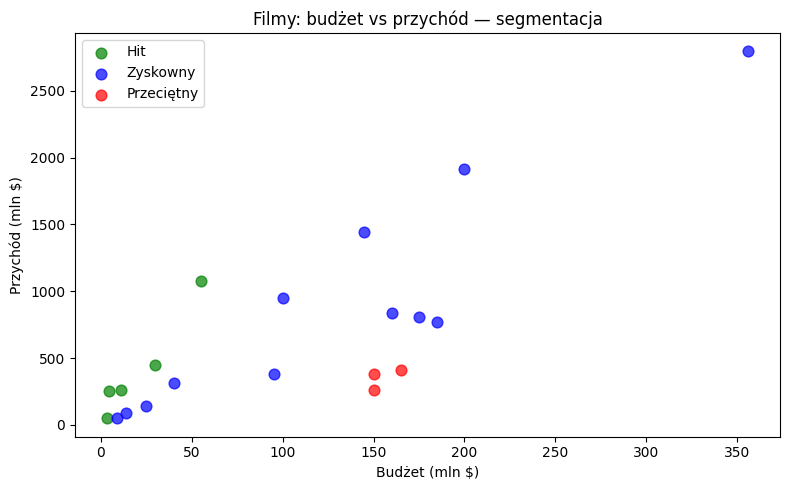

In [68]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
kolory = {'Hit': 'green', 'Zyskowny': 'blue', 'Przeciętny': 'red'}

for seg, kolor in kolory.items():
    dane = filmy[filmy['segment'] == seg]
    ax.scatter(dane['budzet_mln'], dane['przychod_mln'],
            c=kolor, label=seg, s=60, alpha=0.7)

ax.set_xlabel('Budżet (mln $)')
ax.set_ylabel('Przychód (mln $)')
ax.set_title('Filmy: budżet vs przychód — segmentacja')
ax.legend()
plt.tight_layout()
plt.show()

## Zad 4c

Rekomenduję firmie, aby kupowała tanie perełki. Jak widać po wykresie nie trzeba inwestować niesamowicie dużych pieniądzy, aby zysk był kilkokrotnie większy niż budżet.  